# Задание

Уважаемые студенты! Это задание поможет вам освоить ключевые аспекты работы с деревьями решений — одного из самых популярных и интерпретируемых алгоритмов машинного обучения. Вы научитесь строить, анализировать и оптимизировать дерево принятия решений для решения задачи классификации. Также вы оцените качество модели, визуализируете структуру дерева и разработаете стратегию борьбы с переобучением.

Для работы будет использован датасет «Прогнозирование одобрения кредита» (train.csv), содержащий информацию о кредитных заявках: доход заёмщика и созаёмщика, сумма кредита, срок погашения, кредитная история, образование, тип занятости и характеристики недвижимости. Целевая переменная — одобрение кредитной заявки (0 = отклонена, 1 = одобрена).

Выполнив это задание, вы научитесь:
- Проводить предварительный анализ датасета: изучать структуру данных, типы признаков и наличие пропущенных значений.
- Выполнять предобработку данных: удалять нерелевантные признаки, обрабатывать пропуски и кодировать категориальные переменные.
- Строить базовую модель дерева решений с параметрами по умолчанию и оценивать её качество с помощью различных метрик.
- Визуализировать структуру дерева решений и интерпретировать результаты: определять ключевые признаки для разбиения и анализировать важность признаков.
- Оптимизировать гиперпараметры дерева решений для борьбы с переобучением и улучшения обобщающей способности модели.
- Сравнивать метрики качества разных версий модели и делать обоснованные выводы о влиянии гиперпараметров на результат.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка и предварительный анализ данных

Загрузите файл train.csv с помощью библиотеки pandas.

Проведите предварительный анализ данных:
- Изучите структуру датасета, типы данных и наличие пропущенных значений. Обратите внимание на признаки LoanAmount, Credit_History, Gender, Married, Dependents, Self_Employed
- Визуализируйте распределение целевой переменной Loan_Status (преобразуйте 'Y' → 1, 'N' → 0)
- Проанализируйте основные зависимости между признаками и целевой переменной (например, влияние Credit_History и ApplicantIncome на одобрение кредита)

In [4]:
df = pd.read_csv('train.csv')

display(df.head())
display(df.shape)
display(df.columns)
display(df['Loan_Status'].value_counts())

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


(3192, 14)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Employment_Status', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age',
       'Loan_Status'],
      dtype='str')

Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64

In [5]:
df.info()
display(df.describe())
display(df.isna().sum())
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             3192 non-null   str    
 1   Gender              3115 non-null   str    
 2   Married             3126 non-null   str    
 3   Dependents          3192 non-null   int64  
 4   Education           3126 non-null   str    
 5   Employment_Status   3136 non-null   str    
 6   Applicant_Income    3157 non-null   float64
 7   Coapplicant_Income  3192 non-null   float64
 8   Loan_Amount         3151 non-null   float64
 9   Loan_Term           3192 non-null   int64  
 10  Credit_History      3192 non-null   int64  
 11  Property_Area       3192 non-null   str    
 12  Age                 3192 non-null   float64
 13  Loan_Status         3192 non-null   str    
dtypes: float64(4), int64(3), str(7)
memory usage: 349.3 KB


,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Age
count,3192.000000,3157.000000,3192.000000,3151.000000,3192.000000,3192.000000,3192.000000
mean,1.011905,59962.641490,15091.342368,151459.710168,212.368421,0.516917,35.201381
std,0.983975,19932.955795,9541.479521,50313.610809,101.428986,0.499792,7.722665
min,0.000000,15000.000000,0.000000,20000.000000,60.000000,0.000000,21.000000
25%,0.000000,46485.838417,7915.099793,116986.769053,120.000000,0.000000,29.853657
50%,1.000000,60290.179985,14608.469288,151967.787750,240.000000,1.000000,35.054461
75%,2.000000,73118.015531,21758.376019,186201.802079,300.000000,1.000000,40.537728
max,3.000000,138524.754129,47877.611874,373954.212551,360.000000,1.000000,61.159254


Loan_ID                0
Gender                77
Married               66
Dependents             0
Education             66
Employment_Status     56
Applicant_Income      35
Coapplicant_Income     0
Loan_Amount           41
Loan_Term              0
Credit_History         0
Property_Area          0
Age                    0
Loan_Status            0
dtype: int64

np.int64(0)

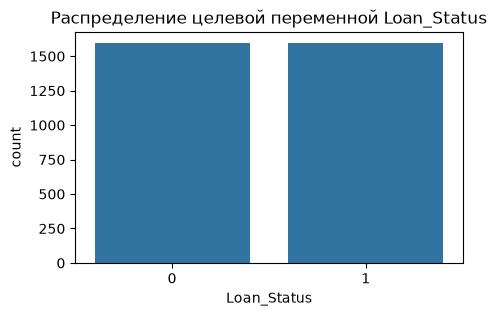

In [6]:
# в данных целевая записана как Approved/Rejected (в задании Y/N), переводим в 0/1
df['Loan_Status'] = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='Loan_Status')
plt.title('Распределение целевой переменной Loan_Status')
plt.show()

Loan_Status,0,1
Credit_History,,
0,0.999351,0.000649
1,0.033333,0.966667


Loan_Status
0    59827.678017
1    60420.076833
Name: Applicant_Income, dtype: float64

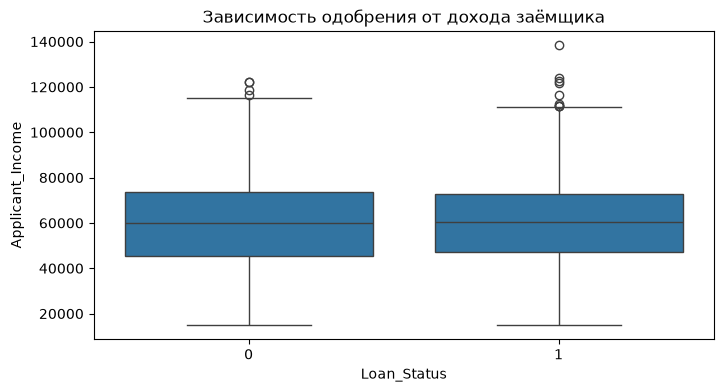

In [7]:
# влияние кредитной истории на одобрение
display(pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index'))

# влияние дохода заёмщика на одобрение
display(df.groupby('Loan_Status')['Applicant_Income'].median())

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Loan_Status', y='Applicant_Income')
plt.title('Зависимость одобрения от дохода заёмщика')
plt.show()

### Выводы по предварительному анализу:

В датасете 3192 строки и 14 колонок, дубликатов нет. Пропуски есть в Gender (77), Married (66), Education (66), Employment_Status (56), Applicant_Income (35) и Loan_Amount (41).

Целевая переменная сбалансирована: одобренных и отклонённых заявок поровну.

Главное, что бросается в глаза: кредитная история почти полностью решает исход. При Credit_History=0 заявка отклоняется в 99.9% случаев, при Credit_History=1 одобряется в 96.7%. Доход заёмщика влияет слабо, медианы практически совпадают (60420 у одобренных против 59828 у отклонённых).

## Предобработка данных

Проведите предобработку данных:
- Удалите столбец Loan_ID, который представляет собой идентификатор заявки и не несёт предсказательной информации
- Обработайте пропущенные значения:
  - Для числовых признаков (LoanAmount) заполните медианой с созданием индикатора пропуска
  - Для категориальных признаков (Gender, Married, Dependents, Self_Employed, Credit_History) заполните модой
- Закодируйте категориальные признаки:
  - Loan_Status (целевая переменная): 'Y' → 1, 'N' → 0
  - Остальные категориальные признаки (Gender, Married, Dependents, Education, Self_Employed, Property_Area) преобразуйте через pd.get_dummies() или OneHotEncoder
- Разделите данные на признаки (X) и целевую переменную (y), затем на обучающую и тестовую выборки (80/20) с параметром stratify=y для сохранения баланса классов

Напишите комментарий о том, как предобработка данных повлияла на качество исходного датасета

In [8]:
from sklearn.model_selection import train_test_split

# убираем Loan_ID, это просто номер заявки, пользы от него для модели нет
df = df.drop('Loan_ID', axis=1)

# делим данные до предобработки, чтобы тест не влиял на неё
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X:', X.shape, '| train:', X_train.shape, '| test:', X_test.shape)

X: (3192, 12) | train: (2553, 12) | test: (639, 12)


In [9]:
# медиану и моду считаем только на train и переносим на тест
loan_median = X_train['Loan_Amount'].median()
income_median = X_train['Applicant_Income'].median()

X_train['Loan_Amount_Missing'] = X_train['Loan_Amount'].isna().astype(int)
X_test['Loan_Amount_Missing'] = X_test['Loan_Amount'].isna().astype(int)

X_train['Loan_Amount'] = X_train['Loan_Amount'].fillna(loan_median)
X_test['Loan_Amount'] = X_test['Loan_Amount'].fillna(loan_median)
X_train['Applicant_Income'] = X_train['Applicant_Income'].fillna(income_median)
X_test['Applicant_Income'] = X_test['Applicant_Income'].fillna(income_median)

for col in ['Gender', 'Married', 'Education', 'Employment_Status', 'Credit_History']:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

print('Пропусков в train:', int(X_train.isna().sum().sum()), '| в test:', int(X_test.isna().sum().sum()))

Пропусков в train: 0 | в test: 0


In [10]:
# One-Hot Encoding, у теста оставляем тот же набор столбцов, что у train
cat_cols = ['Gender', 'Married', 'Education', 'Employment_Status', 'Property_Area']
X_train = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Age,Loan_Amount_Missing,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Employment_Status_Salaried,Employment_Status_Self-Employed,Employment_Status_Unemployed,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
2463,1,92899.354270,0.000000,167554.564584,300,0,31.583735,0,1,0,0,1,1,0,1,0,0,0,0,1
258,0,48168.572223,23569.755370,202086.642633,300,0,29.048281,0,0,1,0,1,1,0,0,1,0,0,0,1
2474,0,65342.533020,19279.626266,109845.770964,300,0,34.291902,0,0,1,0,1,1,0,1,0,0,1,0,0
121,3,36832.706216,9449.832985,54868.688178,180,1,35.800704,0,1,0,0,1,1,0,1,0,0,0,1,0
689,1,62562.088298,4339.678284,140646.286504,240,0,37.911620,0,0,1,0,1,1,0,1,0,0,0,1,0


### Комментарий о предобработке:

Удалили Loan_ID: это просто номер заявки, информации для модели он не даёт.

Пропуски закрыли так: Loan_Amount (41) заполнили медианой и добавили индикатор пропуска Loan_Amount_Missing, Applicant_Income (35) тоже медианой, а категориальные признаки (Gender, Married, Education, Employment_Status, Credit_History) модой. Медиану и моду считали только на обучающей выборке, чтобы тест не влиял на предобработку.

Loan_Status перевели в 0/1, остальные категории закодировали через pd.get_dummies.

На выходе 20 признаков и ни одного пропуска, данные готовы к обучению.

# 2. Построение базовой модели дерева решений

Обучите модель DecisionTreeClassifier из sklearn.tree на обучающей выборке с параметрами по умолчанию.

Сделайте предсказания на тестовой выборке (test.csv).

Оцените качество модели с помощью следующих метрик:
- Accuracy
- Precision, Recall, F1-score (для класса "1" — одобренные заявки)

Постройте матрицу ошибок и визуализируйте ее с помощью seaborn.heatmap.

Сохраните результаты оценки в виде таблицы и графиков.

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall:', round(recall_score(y_test, y_pred), 4))
print('F1-score:', round(f1_score(y_test, y_pred), 4))
print('Train Accuracy:', round(model.score(X_train, y_train), 4))

Accuracy: 0.9671
Precision: 0.9599
Recall: 0.9749
F1-score: 0.9673
Train Accuracy: 1.0


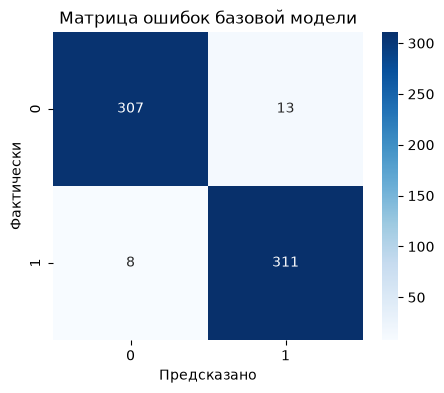

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок базовой модели')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.show()

# 3. Визуализация и интерпретация дерева решений

Визуализируйте построенное дерево с помощью функции plot_tree из sklearn.tree.

Ограничьте глубину до 3 уровней для лучшей читаемости.

Проанализируйте визуализацию и ответьте на следующие вопросы:
- По какому признаку произошло первое разбиение?
- Какие признаки оказались наиболее значимыми? (используйте feature_importances_)
- Как вы думаете, переобучена ли модель? Подтвердите предположение численно

Напишите комментарий о том, насколько дерево решений интерпретируемо и какие закономерности удалось выявить

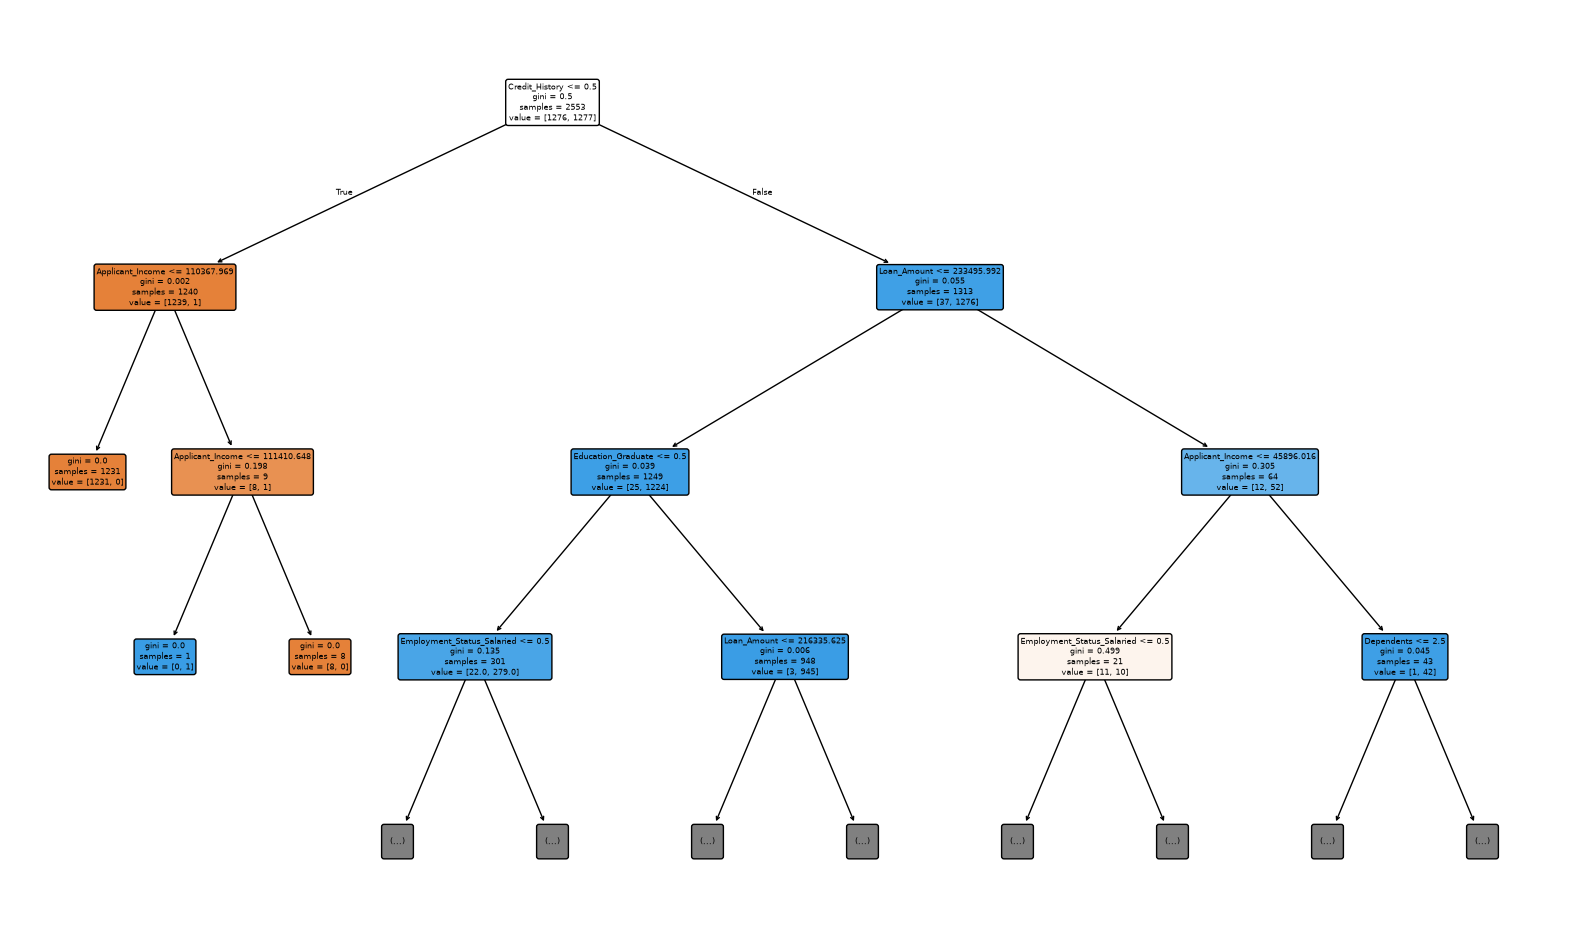

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(model, max_depth=3, feature_names=X_train.columns, filled=True, rounded=True)
plt.show()

In [15]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

Credit_History                0.942097
Applicant_Income              0.016948
Loan_Amount                   0.008810
Property_Area_Urban           0.007558
Employment_Status_Salaried    0.007252
Coapplicant_Income            0.007024
Age                           0.003247
Loan_Term                     0.002243
Education_Graduate            0.001750
Property_Area_Semiurban       0.001671
dtype: float64

### Комментарий об интерпретируемости и переобучении:

Первое разбиение идёт по Credit_History: на картинке видно, что кредитная история сразу делит выборку на почти чистые классы. Она же лидирует и по важности (~94%), остальные признаки (Applicant_Income, Loan_Amount, Property_Area, Employment_Status) заметно отстают.

Модель явно переобучена: на train accuracy = 1.0, то есть дерево просто запомнило выборку, на тесте 0.967. Без ограничений дерево растёт до полного разделения данных и подгоняется под шум.

Зато дерево хорошо интерпретируется: правила и пороговые значения видны напрямую, решение легко объяснить человеку.

# 4. Оптимизация модели и борьба с переобучением

Обучите вторую модель с ограничениями параметров:
- max_depth=5
- min_samples_split=20
- min_samples_leaf=10

Оцените качество второй модели с использованием тех же метрик, что и для первой модели.

Сравните метрики двух моделей и визуализируйте различия.

Проведите эксперимент с настройкой гиперпараметров (дополнительно, необязательно):
- Используйте GridSearchCV для поиска оптимальных параметров
- Сравните качество оптимизированной модели с предыдущими версиями

Напишите подробный комментарий о том, как ограничения повлияли на качество модели и помогли ли они справиться с переобучением

In [16]:
model_opt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
model_opt.fit(X_train, y_train)

y_pred_opt = model_opt.predict(X_test)

In [17]:
print('Accuracy:', round(accuracy_score(y_test, y_pred_opt), 4))
print('Precision:', round(precision_score(y_test, y_pred_opt), 4))
print('Recall:', round(recall_score(y_test, y_pred_opt), 4))
print('F1-score:', round(f1_score(y_test, y_pred_opt), 4))
print('Train Accuracy:', round(model_opt.score(X_train, y_train), 4))

Accuracy: 0.9734
Precision: 0.9494
Recall: 1.0
F1-score: 0.974
Train Accuracy: 0.9875


,Базовая модель,Оптимизированная
Accuracy,0.9671,0.9734
Precision,0.9599,0.9494
Recall,0.9749,1.0000
F1,0.9673,0.9740
Train Accuracy,1.0000,0.9875


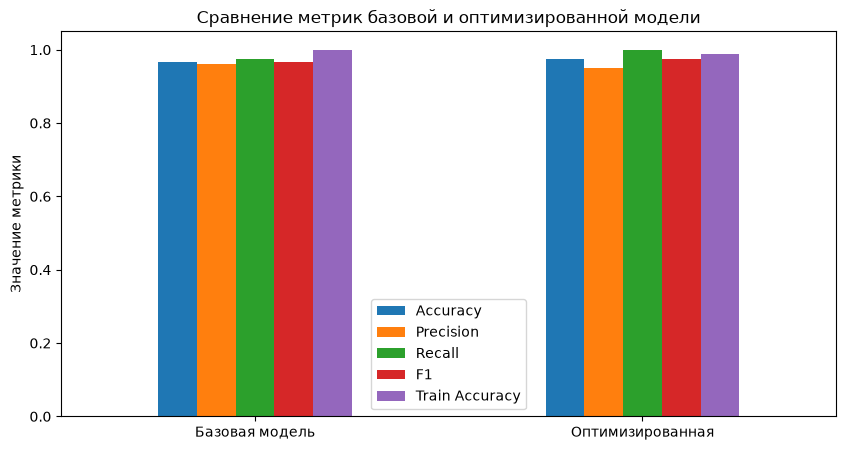

In [18]:
results = pd.DataFrame({
    'Базовая модель': [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                       recall_score(y_test, y_pred), f1_score(y_test, y_pred), model.score(X_train, y_train)],
    'Оптимизированная': [accuracy_score(y_test, y_pred_opt), precision_score(y_test, y_pred_opt),
                         recall_score(y_test, y_pred_opt), f1_score(y_test, y_pred_opt), model_opt.score(X_train, y_train)]
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'Train Accuracy'])

display(results.round(4))

results.T.plot(kind='bar', figsize=(10, 5))
plt.title('Сравнение метрик базовой и оптимизированной модели')
plt.ylabel('Значение метрики')
plt.xticks(rotation=0)
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print('Лучшие параметры:', grid.best_params_)
print('F1 на кросс-валидации:', round(grid.best_score_, 4))
print('F1 на тесте:', round(f1_score(y_test, grid.predict(X_test)), 4))
print('Accuracy на тесте:', round(accuracy_score(y_test, grid.predict(X_test)), 4))

Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 20}
F1 на кросс-валидации: 0.9853
F1 на тесте: 0.966
Accuracy на тесте: 0.9656


### Комментарий о влиянии гиперпараметров:

Ограничения сработали. Train accuracy упал с 1.0 до 0.9875, дерево перестало заучивать выборку, и качество на тесте выросло: F1 0.9673 -> 0.9740, Recall 0.9749 -> 1.0 (не пропустили ни одной одобренной заявки), Accuracy 0.9671 -> 0.9734. Precision немного просел (0.96 -> 0.949), но это ожидаемо: модель стала чаще предсказывать одобрение.

GridSearchCV в качестве бонуса подобрал комбинацию max_depth=3, min_samples_split=20, min_samples_leaf=2 (F1 на кросс-валидации 0.985). На тесте результат получился близким к оптимизированной модели (F1 ~0.966).

# 5. Дополнительный анализ и выводы

Проведите анализ важности признаков для оптимизированной модели.

Визуализируйте важность признаков в виде горизонтального столбчатого графика.

Напишите подробные выводы по работе:
- Какие признаки оказались наиболее значимыми для предсказания одобрения кредитной заявки?
- Как изменение гиперпараметров повлияло на качество и интерпретируемость модели?
- Какие преимущества и недостатки дерева решений проявились при решении данной задачи?
- Предложите возможные пути дальнейшего улучшения модели

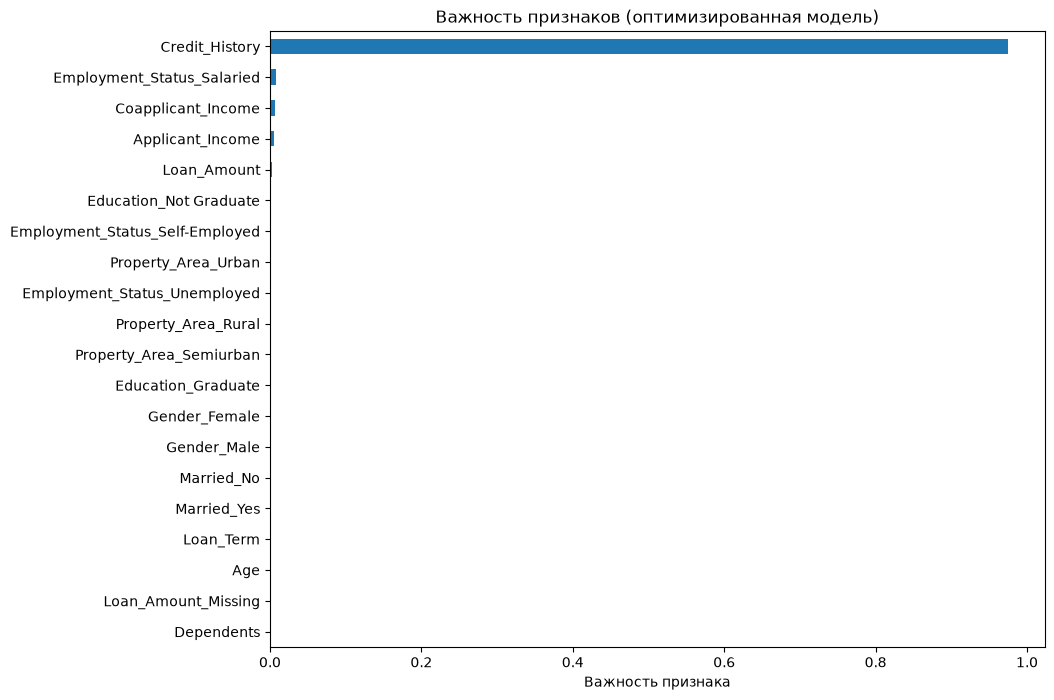

In [20]:
importance_opt = pd.Series(model_opt.feature_importances_, index=X_train.columns)
importance_opt.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Важность признаков (оптимизированная модель)')
plt.xlabel('Важность признака')
plt.show()

### Итоговые выводы:

Модель предсказывает одобрение кредита хорошо: accuracy и F1 ~0.97, а у оптимизированной модели recall = 1.0, то есть находятся все одобренные заявки.

По важности признаков всё однозначно: почти вся предсказательная сила в Credit_History (~97%). Нулевая кредитная история почти гарантирует отказ (99.9% случаев), нормальная - одобрение (96.7%). Доход, сумма кредита, занятость и недвижимость добавляют совсем немного.

Ограничения гиперпараметров (max_depth=5, min_samples_split=20, min_samples_leaf=10) помогли: train accuracy упал с 1.0 до ~0.988, переобучения больше нет, а на тесте стало чуть лучше.

Дерево решений в этой задаче показало себя хорошо: оно простое, наглядное и интерпретируемое, не требует масштабирования признаков. Минусы: без ограничений легко переобучается и нестабильно, чуть изменились данные, и дерево строится уже совсем иначе.

Что можно улучшить дальше: собрать ансамбль (Random Forest или Gradient Boosting), подобрать порог классификации, добавить признаков (число кредитов, стаж, кредитная нагрузка) и меньше опираться на один доминирующий признак.